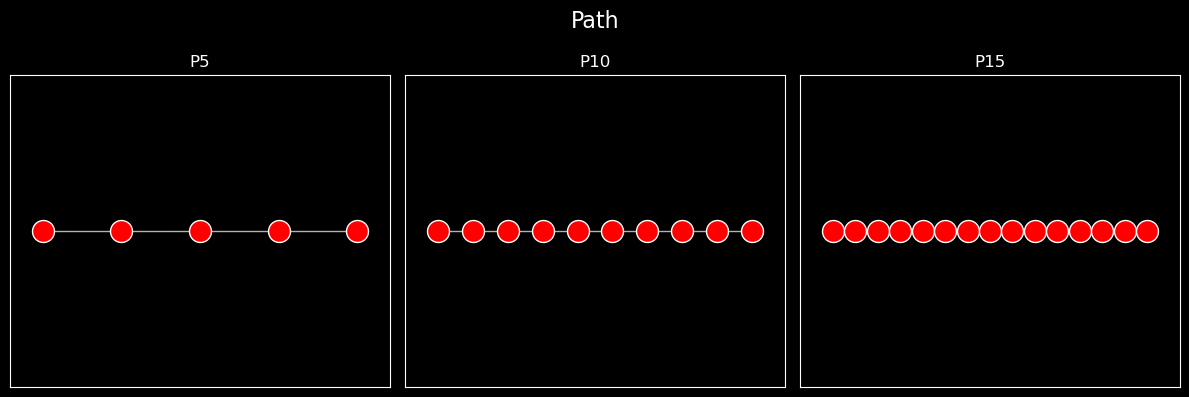

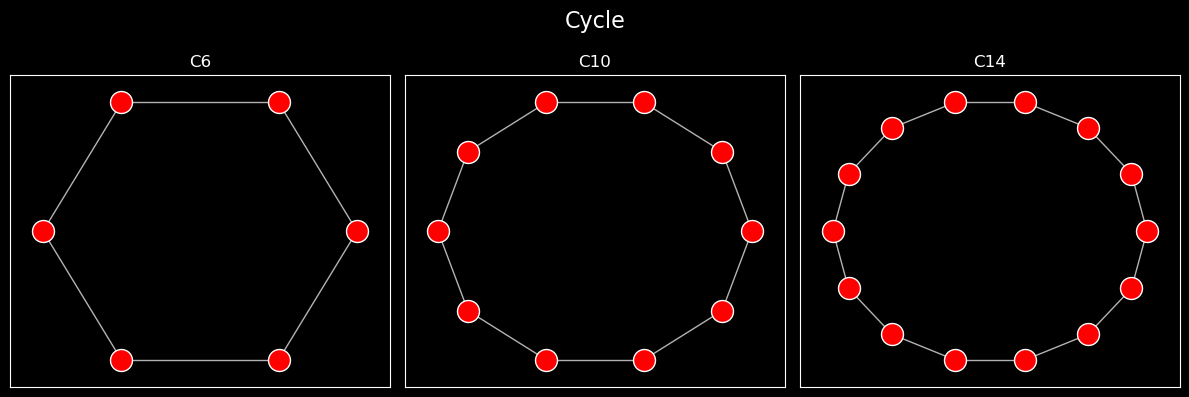

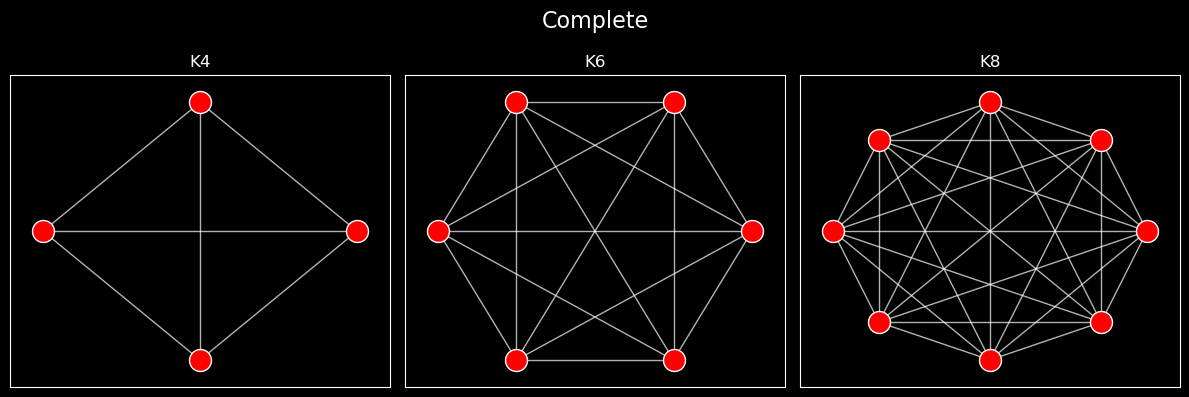

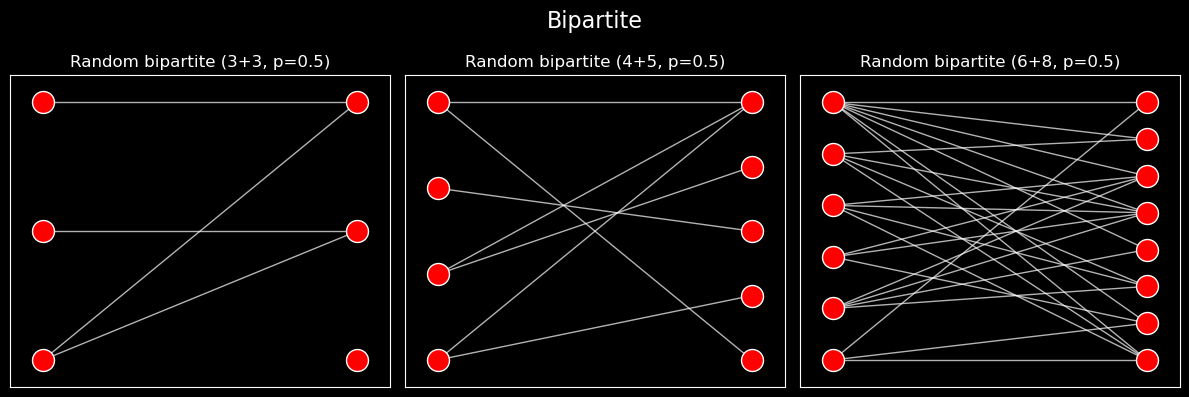

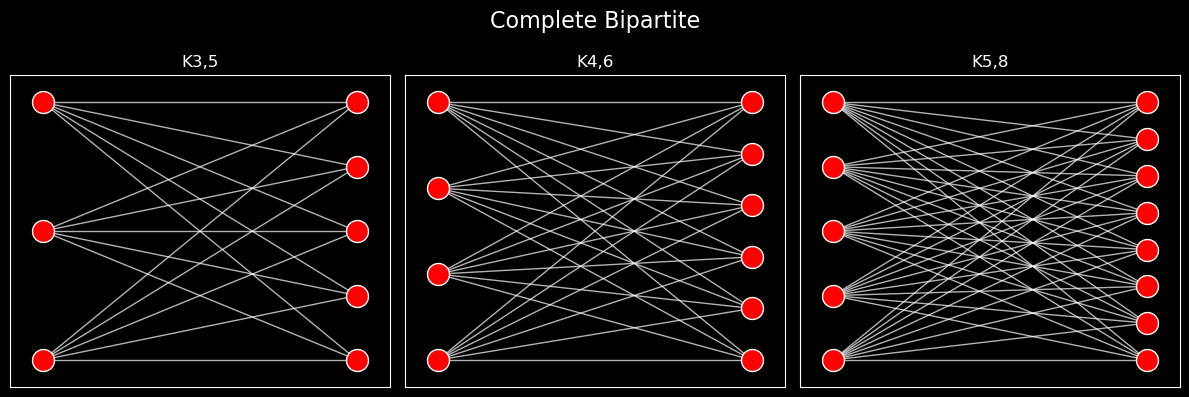

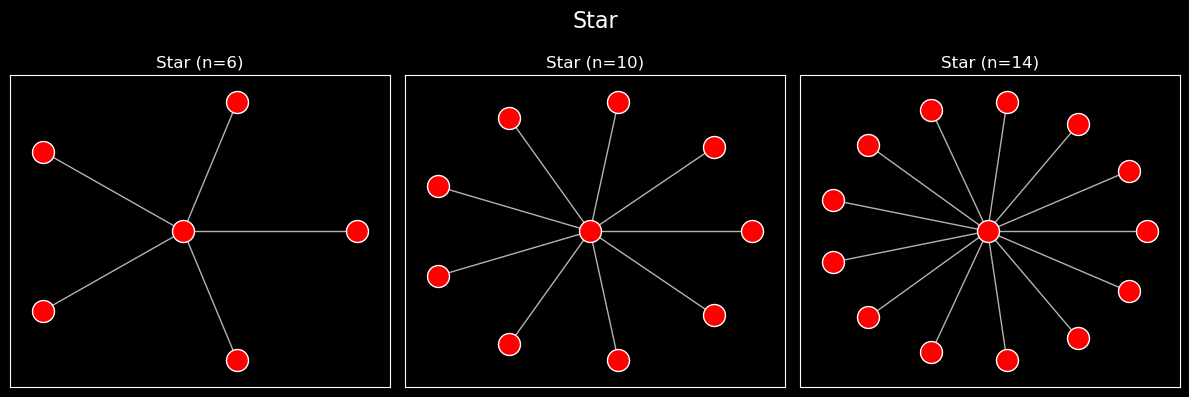

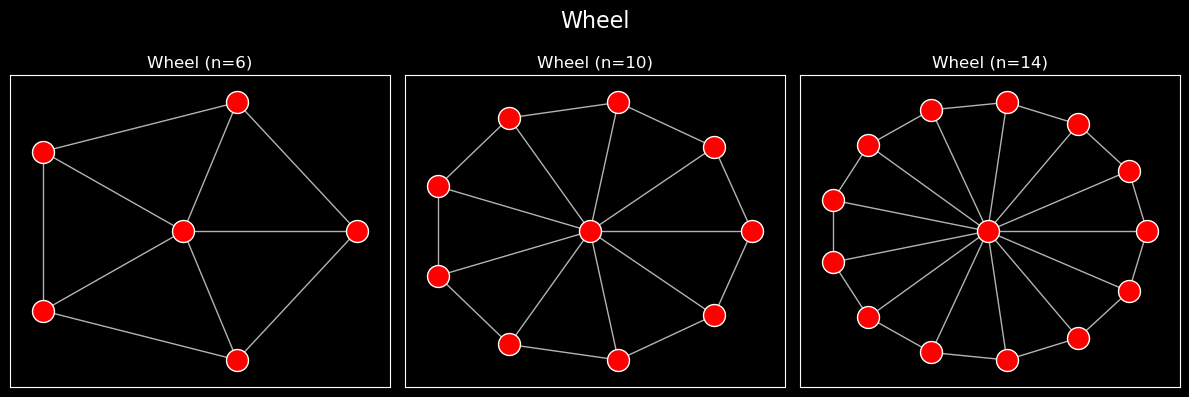

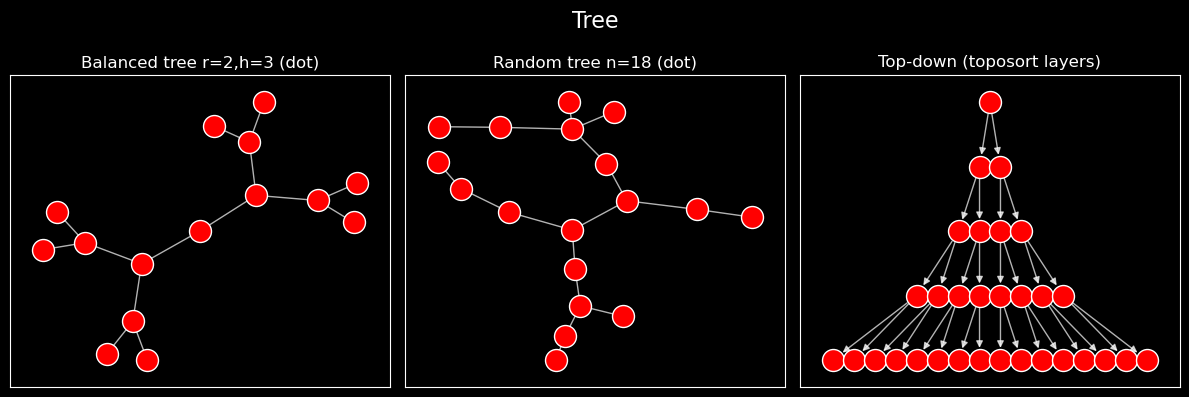

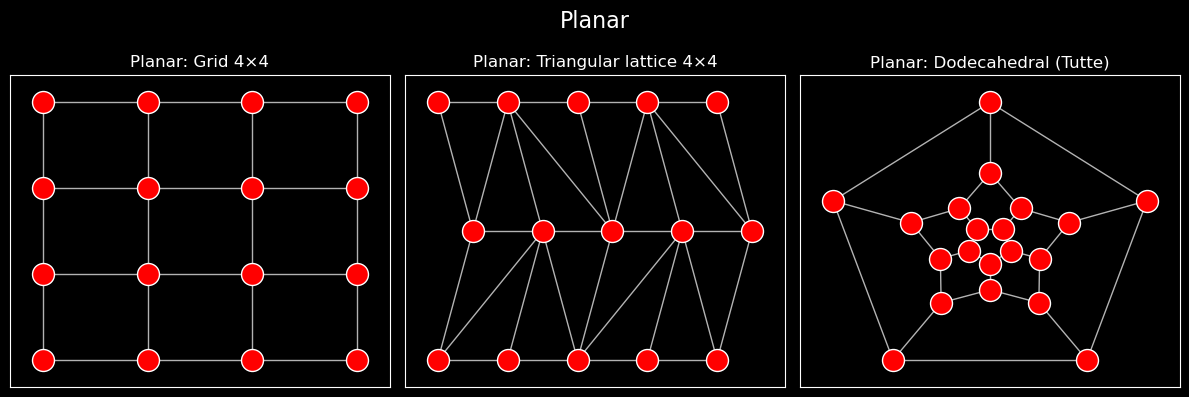

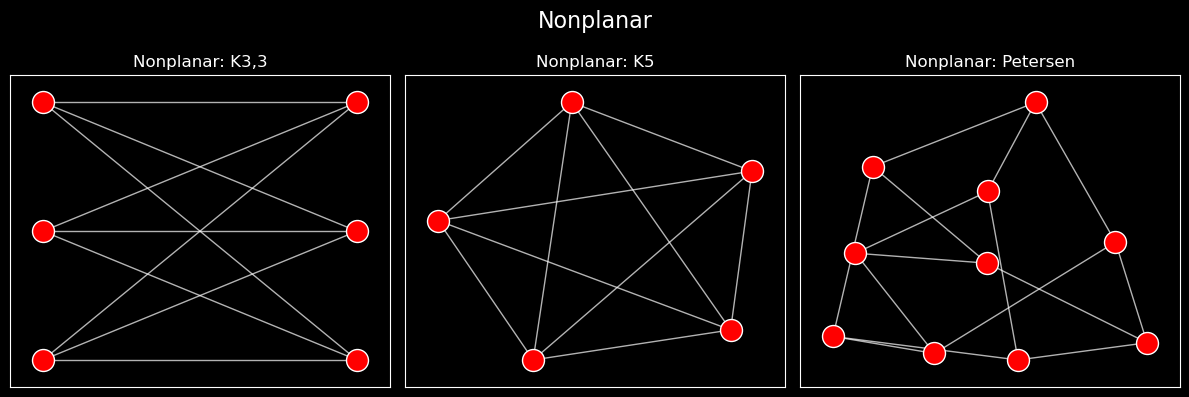

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

plt.style.use("dark_background")

# ============================================================
# USER CONTROLS
# ============================================================
NODE_SIZE = 250       # <-- node size control
EDGE_WIDTH = 1.0
EDGE_ALPHA = 0.70

NODE_COLOR = "red"
EDGE_COLOR = "white"
GRID_ALPHA = 0.0

RNG = np.random.default_rng()


# ============================================================
# Drawing helper (keeps the "old" look)
# ============================================================
def draw_graph(ax, G, pos, title):

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color=EDGE_COLOR,
        alpha=EDGE_ALPHA,
        width=EDGE_WIDTH
    )

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=NODE_COLOR,
        edgecolors="white",
        node_size=NODE_SIZE
    )

    ax.set_title(title, color="white")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.tick_params(colors="white", labelbottom=False, labelleft=False)


# ============================================================
# Natural layouts (by family)
# ============================================================
def pos_path(G):
    nodes = sorted(G.nodes())
    return {n: (i, 0.0) for i, n in enumerate(nodes)}

def pos_cycle(G):
    return nx.circular_layout(G)

def pos_complete(G):
    return nx.circular_layout(G)

def pos_star(G, center=0):
    leaves = [n for n in G.nodes() if n != center]
    pos = {center: (0.0, 0.0)}
    if len(leaves) == 0:
        return pos
    angles = np.linspace(0, 2*np.pi, len(leaves), endpoint=False)
    for a, node in zip(angles, leaves):
        pos[node] = (np.cos(a), np.sin(a))
    return pos

def pos_wheel(G):
    # nx.wheel_graph(n): node 0 is the hub
    hub = 0
    rim = [n for n in G.nodes() if n != hub]
    pos = {hub: (0.0, 0.0)}
    angles = np.linspace(0, 2*np.pi, len(rim), endpoint=False)
    for a, node in zip(angles, rim):
        pos[node] = (np.cos(a), np.sin(a))
    return pos

def pos_bipartite(G, left_nodes):
    return nx.bipartite_layout(G, left_nodes)

def pos_tree_graphviz_or_spring(G, root=0):
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        return graphviz_layout(G, prog="dot", root=root)
    except Exception:
        return nx.spring_layout(G, seed=42)

def pos_tree_topdown_from_toposort(DG, root=0):
    """
    DG: directed tree rooted at 'root'
    Position by depth (top to bottom) and topological order within each depth.
    """
    topo = list(nx.topological_sort(DG))

    depth = {root: 0}
    for u in topo:
        for v in DG.successors(u):
            depth[v] = depth[u] + 1

    max_d = max(depth.values()) if depth else 0
    levels = {d: [] for d in range(max_d + 1)}
    for n in topo:
        levels[depth[n]].append(n)

    pos = {}
    for d in range(max_d + 1):
        nodes = levels[d]
        k = len(nodes)
        if k == 0:
            continue
        xs = np.arange(k, dtype=float) - (k - 1) / 2.0
        y = -float(d)
        for x, n in zip(xs, nodes):
            pos[n] = (float(x), y)

    return pos

def pos_nonplanar(G):
    return nx.spring_layout(G, seed=42)


# ============================================================
# Variants per kind (each returns list of (title, G, pos_fn))
# ============================================================
def variants_path():
    return [
        ("P5",  nx.path_graph(5),  pos_path),
        ("P10", nx.path_graph(10), pos_path),
        ("P15", nx.path_graph(15), pos_path),
    ]

def variants_cycle():
    return [
        ("C6",  nx.cycle_graph(6),  pos_cycle),
        ("C10", nx.cycle_graph(10), pos_cycle),
        ("C14", nx.cycle_graph(14), pos_cycle),
    ]

def variants_complete():
    return [
        ("K4", nx.complete_graph(4), pos_complete),
        ("K6", nx.complete_graph(6), pos_complete),
        ("K8", nx.complete_graph(8), pos_complete),
    ]

def variants_bipartite():
    out = []
    specs = [(3, 3, 0.5), (4, 5, 0.5), (6, 8, 0.5)]
    for (a, b, p) in specs:
        seed = int(RNG.integers(0, 1_000_000))
        G = nx.bipartite.random_graph(a, b, p, seed=seed)
        left = list(range(a))
        out.append((f"Random bipartite ({a}+{b}, p={p})", G, lambda GG, L=left: pos_bipartite(GG, L)))
    return out

def variants_complete_bipartite():
    out = []
    for a, b in [(3, 5), (4, 6), (5, 8)]:
        G = nx.complete_bipartite_graph(a, b)
        left = list(range(a))
        out.append((f"K{a},{b}", G, lambda GG, L=left: pos_bipartite(GG, L)))
    return out

def variants_star():
    # nx.star_graph(k) has k+1 nodes (hub 0 + k leaves)
    return [
        ("Star (n=6)",  nx.star_graph(5),  lambda GG: pos_star(GG, center=0)),
        ("Star (n=10)", nx.star_graph(9),  lambda GG: pos_star(GG, center=0)),
        ("Star (n=14)", nx.star_graph(13), lambda GG: pos_star(GG, center=0)),
    ]

def variants_wheel():
    return [
        ("Wheel (n=6)",  nx.wheel_graph(6),  pos_wheel),
        ("Wheel (n=10)", nx.wheel_graph(10), pos_wheel),
        ("Wheel (n=14)", nx.wheel_graph(14), pos_wheel),
    ]

def variants_tree():
    # 1) graphviz "dot" style (if available)
    T1 = nx.balanced_tree(r=2, h=3)
    # 2) random tree
    T2 = nx.random_tree(18, seed=int(RNG.integers(0, 1_000_000)))
    # 3) top-down toposort layout on a directed rooted tree
    T3 = nx.balanced_tree(r=2, h=4)
    DG3 = nx.bfs_tree(T3, source=0)  # directed outward from root

    return [
        ("Balanced tree r=2,h=3 (dot)", T1, lambda GG: pos_tree_graphviz_or_spring(GG, root=0)),
        ("Random tree n=18 (dot)",      T2, lambda GG: pos_tree_graphviz_or_spring(GG, root=0)),
        ("Top-down (toposort layers)",  DG3, lambda GG: pos_tree_topdown_from_toposort(GG, root=0)),
    ]

def variants_planar():
    # ---- (1) Grid: explicit lattice coords ----
    def grid_graph(rows=4, cols=4):
        G = nx.grid_2d_graph(rows, cols)
        pos = {(i, j): (j, -i) for i in range(rows) for j in range(cols)}
        return G, pos

    # ---- (2) Triangular lattice: explicit triangular coords ----
    def triangular_lattice(rows=4, cols=4):
        G = nx.triangular_lattice_graph(rows, cols)
        h = np.sqrt(3) / 2.0
        pos = {}
        for (i, j) in G.nodes():
            x = j + 0.5 * (i % 2)
            y = -i * h
            pos[(i, j)] = (x, y)
        return G, pos

    # ---- (3) Dodecahedral: Tutte embedding with a TRUE pentagonal face as outer boundary ----
    def dodecahedral_tutte():
        G = nx.dodecahedral_graph()
        is_planar, emb = nx.check_planarity(G)
        if not is_planar:
            raise RuntimeError("Dodecahedral graph should be planar, but planarity check failed.")

        # Extract faces from the planar embedding
        seen_half_edges = set()
        faces = []
        for v in emb:
            for w in emb.neighbors_cw_order(v):
                if (v, w) in seen_half_edges:
                    continue
                face = emb.traverse_face(v, w, mark_half_edges=seen_half_edges)
                faces.append(face)

        # Pick one pentagonal face as the outer boundary (dodeca faces are all length-5)
        outer = None
        for f in faces:
            if len(f) == 5:
                outer = f
                break
        if outer is None:
            # fallback: any 5-cycle
            for f in nx.cycle_basis(G):
                if len(f) == 5:
                    outer = f
                    break
        if outer is None:
            raise RuntimeError("Could not find a pentagonal face/cycle for the dodecahedron.")

        boundary = list(outer)
        boundary_set = set(boundary)

        # Fix boundary vertices on a regular pentagon
        R = 3.0
        angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, len(boundary), endpoint=False)
        fixed = {v: (R * np.cos(a), R * np.sin(a)) for v, a in zip(boundary, angles)}

        interior = [v for v in G.nodes() if v not in boundary_set]
        idx = {v: i for i, v in enumerate(interior)}
        k = len(interior)

        A = np.zeros((k, k), dtype=float)
        bx = np.zeros(k, dtype=float)
        by = np.zeros(k, dtype=float)

        for v in interior:
            i = idx[v]
            deg = G.degree(v)
            A[i, i] = deg

            for u in G.neighbors(v):
                if u in boundary_set:
                    bx[i] += fixed[u][0]
                    by[i] += fixed[u][1]
                else:
                    j = idx[u]
                    A[i, j] -= 1.0

        x = np.linalg.solve(A, bx)
        y = np.linalg.solve(A, by)

        pos = {v: fixed[v] for v in boundary}
        for v in interior:
            i = idx[v]
            pos[v] = (float(x[i]), float(y[i]))

        return G, pos

    G1, P1 = grid_graph(4, 4)
    G2, P2 = triangular_lattice(4, 4)
    G3, P3 = dodecahedral_tutte()

    return [
        ("Planar: Grid 4×4",               G1, lambda GG, P=P1: P),
        ("Planar: Triangular lattice 4×4", G2, lambda GG, P=P2: P),
        ("Planar: Dodecahedral (Tutte)",   G3, lambda GG, P=P3: P),
    ]

def variants_nonplanar():
    G1 = nx.complete_bipartite_graph(3, 3)   # K3,3
    left = list(range(3))
    G2 = nx.complete_graph(5)                # K5
    G3 = nx.petersen_graph()                 # classic nonplanar

    return [
        ("Nonplanar: K3,3",     G1, lambda GG, L=left: pos_bipartite(GG, L)),
        ("Nonplanar: K5",       G2, pos_nonplanar),
        ("Nonplanar: Petersen", G3, pos_nonplanar),
    ]


# ============================================================
# Master registry (order requested)
# ============================================================
GRAPH_KINDS = {
    "Path": variants_path,
    "Cycle": variants_cycle,
    "Complete": variants_complete,
    "Bipartite": variants_bipartite,
    "Complete Bipartite": variants_complete_bipartite,
    "Star": variants_star,
    "Wheel": variants_wheel,
    "Tree": variants_tree,
    "Planar": variants_planar,
    "Nonplanar": variants_nonplanar,
}


# ============================================================
# Plot: for each kind, 1×N horizontal row of examples
# ============================================================
for kind, builder in GRAPH_KINDS.items():
    variants = builder()
    n = len(variants)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, (title, G, pos_fn) in zip(axes, variants):
        pos = pos_fn(G)
        draw_graph(ax, G, pos, title)

    fig.suptitle(kind, color="white", fontsize=16)
    plt.tight_layout()
    plt.show()